### Task: Monthly Cohort & Performer Analysis

Build a monthly cohort report from relational product tables (`users`, `codesubmit`, `transaction`, `language`) to track:
* **Active User Rate:** Percentage of active users grouped by registration month
* **Task Performance:** Total vs. successful code submissions per month
* **Cumulative Revenue:** Running revenue growth without join duplication
* **Top 5% Performers:** Dynamically extract the top 5% of programmers per language based on successful submissions
* **Growth Filter:** Return only cohorts where revenue grew compared to the previous month

### Note on Dataset: 
**This pipeline was developed and stress-tested using an anonymized, synthetic relational dataset designed to validate complex SQL edge cases (multi-tier CTEs, percentile rank distributions, and window-based MoM revenue comparisons), so outcomes and plots may look "unrealistic"**

In [1]:
import datetime
import pandas as pd
from sqlalchemy import create_engine

# set up in-memory sqlite instance
engine = create_engine("sqlite:///:memory:")

# load raw datasets
users = pd.read_csv('users.csv')
codesubmit = pd.read_csv('codesubmit.csv')
transaction = pd.read_csv('transaction.csv')
language = pd.read_csv('language.csv')

# push tables to sqlite
users.to_sql("users", engine, index=False)
codesubmit.to_sql("codesubmit", engine, index=False)
transaction.to_sql("transaction", engine, index=False)
language.to_sql("language", engine, index=False)

advanced_cohort_query = """
WITH 
-- 1. active user share by registration month--
us_agg AS (
    SELECT
        strftime('%Y-%m', date_joined) AS YM,
        ROUND(
            (
                COUNT(CASE WHEN is_active = 1 THEN 1 END) * 100.0
            ) / COUNT(id),
            1
        ) AS active_user_pct
    FROM
        users
    GROUP BY
        strftime('%Y-%m', date_joined)
),

-- 2. total vs successful code submissions per month --
codesubmit_per_month AS (
    SELECT
        strftime('%Y-%m', created_at) AS YM,
        COUNT(*) AS total_submissions,
        COUNT(CASE WHEN is_false = 0 THEN 1 END) AS successful_submissions
    FROM
        codesubmit
    GROUP BY
        strftime('%Y-%m', created_at)
),

-- 3. monthly revenue and running cumulative max--
month_revenue AS (
    SELECT
        strftime('%Y-%m', created_at) AS YM,
        SUM(COALESCE(value, 0)) AS monthly_revenue,
        MAX(SUM(COALESCE(value, 0))) OVER (
            ORDER BY strftime('%Y-%m', created_at)
        ) AS running_max_revenue
    FROM
        "transaction"
    GROUP BY
        strftime('%Y-%m', created_at)
),

-- 4. attempts and successful tasks per user by language --
code_lang AS (
    SELECT
        strftime('%Y-%m', cs.created_at) AS YM,
        l.name AS language_name,
        cs.user_id,
        COUNT(cs.user_id) AS total_user_tries,
        COUNT(CASE WHEN cs.is_false = 0 THEN 1 END) AS successful_submissions_count
    FROM
        codesubmit cs
        LEFT JOIN language l ON cs.language_id = l.id
    GROUP BY
        strftime('%Y-%m', cs.created_at),
        l.name,
        cs.user_id
),

-- 5. calculate percentile ranks within each language and month --
five_perc_prep AS (
    SELECT
        YM,
        language_name,
        successful_submissions_count,
        PERCENT_RANK() OVER (
            PARTITION BY YM, language_name 
            ORDER BY successful_submissions_count ASC
        ) AS p_rank
    FROM
        code_lang
),

-- 6. find the 95th percentile threshold --
five_perc AS (
    SELECT
        YM,
        language_name,
        MIN(successful_submissions_count) AS threshold_top_5_pct
    FROM
        five_perc_prep
    WHERE
        p_rank >= 0.95
    GROUP BY
        YM,
        language_name
),

-- 7. compile comma-separated list of top 5% programmers --
top5per_us AS (
    SELECT
        fp.YM,
        fp.language_name,
        fp.threshold_top_5_pct,
        GROUP_CONCAT(CAST(cl.user_id AS TEXT), ', ') AS top_programmers_list
    FROM
        code_lang cl
        INNER JOIN five_perc fp 
            ON cl.YM = fp.YM 
            AND cl.language_name = fp.language_name
    WHERE
        cl.successful_submissions_count >= fp.threshold_top_5_pct
    GROUP BY
        fp.YM,
        fp.language_name,
        fp.threshold_top_5_pct
),

-- 8. join CTEs and pull previous month's revenue for comparison --
for_last AS (
    SELECT
        u.YM,
        u.active_user_pct,
        tf.language_name,
        c.total_submissions,
        c.successful_submissions,
        m.monthly_revenue,
        m.running_max_revenue,
        LAG(m.monthly_revenue) OVER (
            PARTITION BY tf.language_name
            ORDER BY u.YM ASC
        ) AS prev_month_revenue,
        tf.top_programmers_list
    FROM
        us_agg u
        LEFT JOIN codesubmit_per_month c ON u.YM = c.YM
        LEFT JOIN month_revenue m ON u.YM = m.YM
        LEFT JOIN top5per_us tf ON u.YM = tf.YM
    WHERE
        m.monthly_revenue IS NOT NULL
        AND tf.language_name IS NOT NULL
)

-- 9. keep only cohorts where revenue grew month-over-month --
SELECT
    YM,
    active_user_pct,
    language_name,
    total_submissions,
    successful_submissions,
    monthly_revenue,
    prev_month_revenue,
    top_programmers_list
FROM
    for_last
WHERE
    monthly_revenue >= prev_month_revenue
    AND prev_month_revenue IS NOT NULL
ORDER BY
    YM ASC,
    language_name ASC;
"""

with engine.connect() as conn:
    cohort_report_df = pd.read_sql_query(advanced_cohort_query, conn)

cohort_report_df

### Note on Dataset: 
#This pipeline was developed and stress-tested using an anonymized, synthetic relational dataset designed to validate 
#complex SQL edge cases (multi-tier CTEs, percentile rank distributions, and window-based MoM revenue comparisons), so outcomes and plots may look "unrealistic"

,YM,active_user_pct,language_name,total_submissions,successful_submissions,monthly_revenue,prev_month_revenue,top_programmers_list
0,2021-11,91.4,Python,1798,855,388328.0,69.0,"63, 139, 176, 244"
1,2021-11,91.4,SQL,1798,855,388328.0,69.0,"63, 222, 233"
2,2022-01,85.4,Python,4688,1646,64194.0,28302.0,"121, 342, 363, 477, 509, 570, 614"
3,2022-01,85.4,SQL,4688,1646,64194.0,28302.0,"286, 342, 411, 416, 551, 589, 614, 623"
4,2022-02,87.7,Python,4573,1649,113606.0,64194.0,"438, 628, 743, 815, 1141, 1426, 1439, 1495, 1544"
5,2022-02,87.7,SQL,4573,1649,113606.0,64194.0,"258, 934, 1012, 1050, 1090, 1294, 1663, 1709, ..."


### Seaborn and Plotly Visualisation

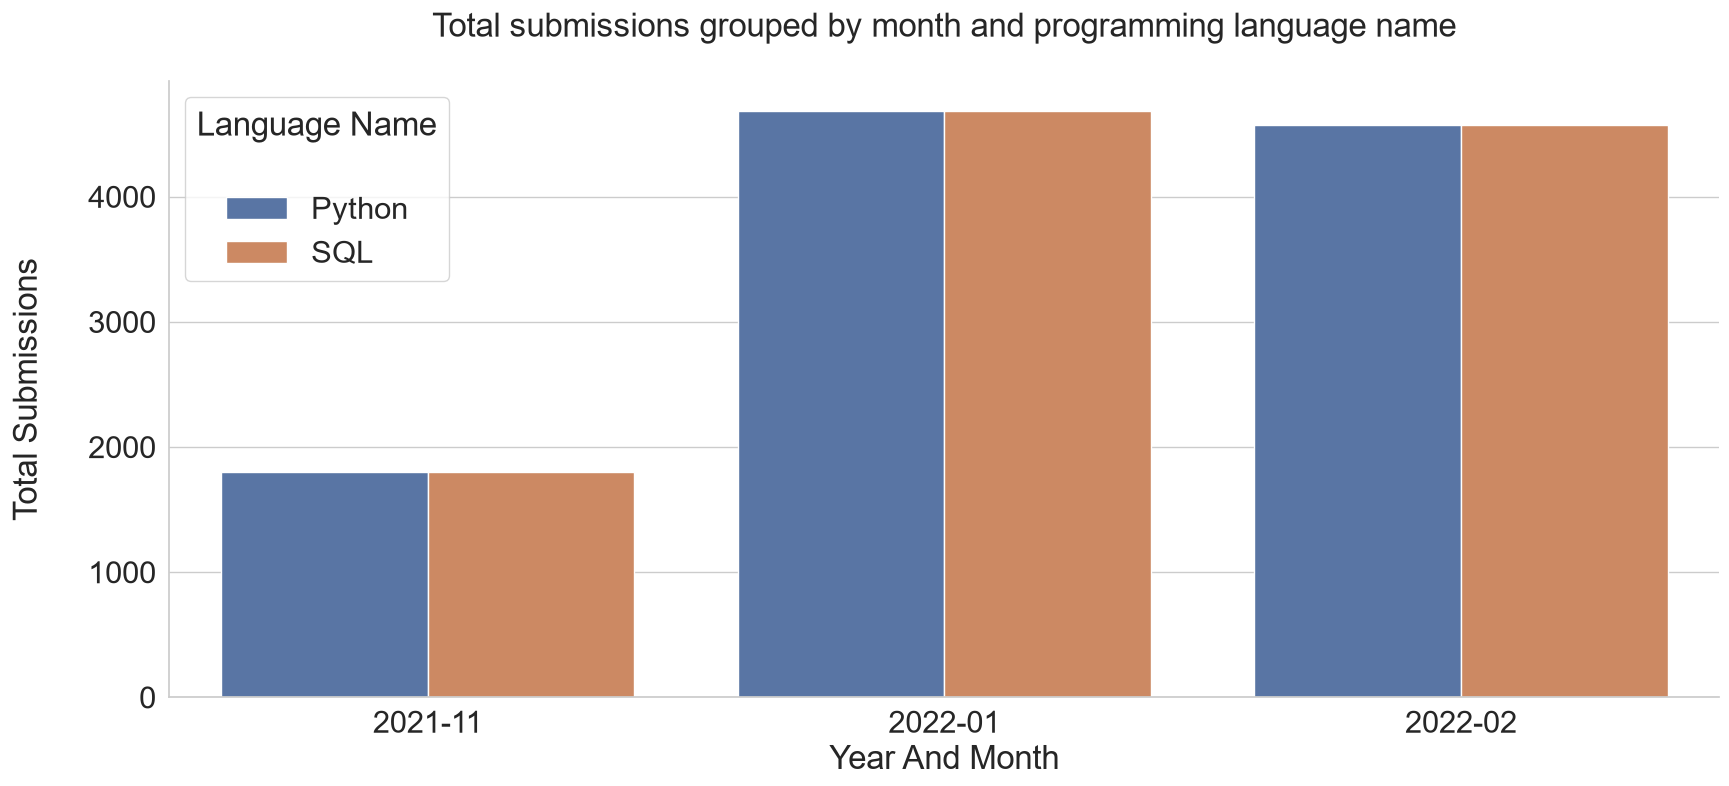

In [30]:
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
sns.set(font_scale=2, style="whitegrid", rc={"figure.figsize": (20, 8)})
ax = sns.barplot(data = cohort_report_df, x = 'YM', y = 'total_submissions',hue = 'language_name')
ax.set_title('Total submissions grouped by month and programming language name\n')
ax.set_ylabel('Total Submissions\n')
ax.set_xlabel('Year And Month')
ax.legend(title = 'Language Name\n')
sns.despine()

In [61]:
ax = px.bar(cohort_report_df, x = 'YM', y = 'total_submissions',color = 'language_name', barmode = 'group', height= 650, width= 1300,
    title = 'Total submissions grouped by month and programming language name' ,labels = {
        'YM':'Year And Month',
        'language_name':'Language Name',
        'total_submissions':'Total Submissions'
})
ax.update_xaxes(type='category')